In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/drive/MyDrive/Kolam dataset work/Train"
val_dir   = "/content/drive/MyDrive/Kolam dataset work/val"
test_dir  = "/content/drive/MyDrive/Kolam dataset work/test"

# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation/test should not be augmented
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1012 images belonging to 6 classes.
Found 213 images belonging to 6 classes.
Found 218 images belonging to 6 classes.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics= ['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Kolam dataset work/Train"):
    for f in files:
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            print("⚠️ Non-image file found:", os.path.join(root, f))


In [ ]:
from PIL import Image

bad_files = []
root_dir = "/content/drive/MyDrive/Kolam dataset work/Train"

for root, dirs, files in os.walk(root_dir):
    for f in files:
        path = os.path.join(root, f)
        try:
            img = Image.open(path)
            img.verify()  # check if image can be opened
        except Exception as e:
            bad_files.append(path)

print("Bad files:", bad_files)


Bad files: ['/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_24.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_3.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_28.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_138.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_82.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_121.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_73.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_53.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_126.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_88.jpg', '/content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_2.jpg', '/content/drive/MyDrive/Kolam dataset wor

In [ ]:
for bf in bad_files:
    os.remove(bf)
    print("Removed:", bf)


Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_24.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_3.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_28.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_138.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_82.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_121.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_73.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_53.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_126.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala kolam_88.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/Train/Mandala_Kolam/mandala

In [ ]:
from PIL import Image

bad_files = []
root_dir = "/content/drive/MyDrive/Kolam dataset work/test"

for root, dirs, files in os.walk(root_dir):
    for f in files:
        path = os.path.join(root, f)
        try:
            img = Image.open(path)
            img.verify()  # check if image can be opened
        except Exception as e:
            bad_files.append(path)

print("Bad files:", bad_files)


Bad files: ['/content/drive/MyDrive/Kolam dataset work/test/maa kolam test/maa kolam wet rice kolam_170.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_147.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_161.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_162.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_150.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_167.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_164.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_148.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_158.jpg', '/content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_168.jpg', '/content/drive/MyDrive/Kolam dataset work/test/freehand kolam test/fre

In [ ]:
for bf in bad_files:
    os.remove(bf)
    print("Removed:", bf)


Removed: /content/drive/MyDrive/Kolam dataset work/test/maa kolam test/maa kolam wet rice kolam_170.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_147.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_161.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_162.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_150.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_167.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_164.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_148.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_158.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/test/mandala kolam test/mandala kolam_168.jpg
Removed: /content/drive

In [ ]:
from PIL import Image

bad_files = []
root_dir = "/content/drive/MyDrive/Kolam dataset work/val"

for root, dirs, files in os.walk(root_dir):
    for f in files:
        path = os.path.join(root, f)
        try:
            img = Image.open(path)
            img.verify()  # check if image can be opened
        except Exception as e:
            bad_files.append(path)

print("Bad files:", bad_files)

Bad files: ['/content/drive/MyDrive/Kolam dataset work/val/maa kolam vel/maa kolam wet rice kolam_176.jpg', '/content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_141.jpg', '/content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_167.jpg', '/content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_165.jpg', '/content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_150.jpg', '/content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_143.jpg', '/content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_194.jpg', '/content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_198.jpg', '/content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_173.jpg', '/content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_172.jpg', '/content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_18

In [ ]:
for bf in bad_files:
    os.remove(bf)
    print("Removed:", bf)

Removed: /content/drive/MyDrive/Kolam dataset work/val/maa kolam vel/maa kolam wet rice kolam_176.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_141.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_167.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_165.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_150.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/freehand kolam vel/freehand kolam_143.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_194.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_198.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_173.jpg
Removed: /content/drive/MyDrive/Kolam dataset work/val/mandala kolam vel/mandala kolam_172.jpg
Removed: /content/drive/MyDrive/K

In [ ]:
import os

file_path = "/content/drive/MyDrive/Kolam dataset work/Train/Freehand_Kolam/freehand kolam_89.jpg"
print("Exists?", os.path.exists(file_path))


Exists? False


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 333s 10s/step - accuracy: 0.5595 - loss: 1.2210 - val_accuracy: 0.8169 - val_loss: 0.4794
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8150 - loss: 0.4898 - val_accuracy: 0.8685 - val_loss: 0.3407
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8688 - loss: 0.3587 - val_accuracy: 0.9202 - val_loss: 0.2618
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.8990 - loss: 0.2885 - val_accuracy: 0.9249 - val_loss: 0.2288
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8940 - loss: 0.2519 - val_accuracy: 0.9531 - val_loss: 0.1769
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9444 - loss: 0.1838 - val_accuracy: 0.9531 - val_loss: 0.1637
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9463 - loss: 0.1798 - val_accuracy: 0.9577 - val_loss: 0.1575
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9543 - loss: 0.1506 - val_accuracy: 0.9765 - val_los

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("✅ Test Accuracy:", test_acc)


7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.9430 - loss: 0.1721
✅ Test Accuracy: 0.9495412707328796


In [ ]:
import cv2
import os

img_path = "/content/drive/MyDrive/test_image.jpg"

print("Exists?", os.path.exists(img_path))   # check if path is correct

img = cv2.imread(img_path)
print("Loaded:", img is not None)            # check if OpenCV loaded it


Exists? False
Loaded: False


In [ ]:
from google.colab.patches import cv2_imshow  # for showing images in Colab
import cv2
import numpy as np
import os

def predict_kolam(img_path):
    # Check if file exists
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"❌ Image not found: {img_path}")

    # Load image with OpenCV
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"❌ Failed to load image: {img_path}. Check format.")

    # Preprocess image
    img_resized = cv2.resize(img, (224, 224))  # resize to match model input
    img_array = img_resized.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    class_labels = list(train_generator.class_indices.keys())
    predicted_class = class_labels[class_idx]

    # Show image with label
    cv2.putText(img, predicted_class, (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
                1, (0, 255, 0), 2)
    cv2_imshow(img)

    return predicted_class

# ✅ Example usage with the correct path
print("Predicted:", predict_kolam("/content/drive/MyDrive/mandala kolam_6jpg"))


FileNotFoundError: ❌ Image not found: /content/drive/MyDrive/mandala kolam_6jpg

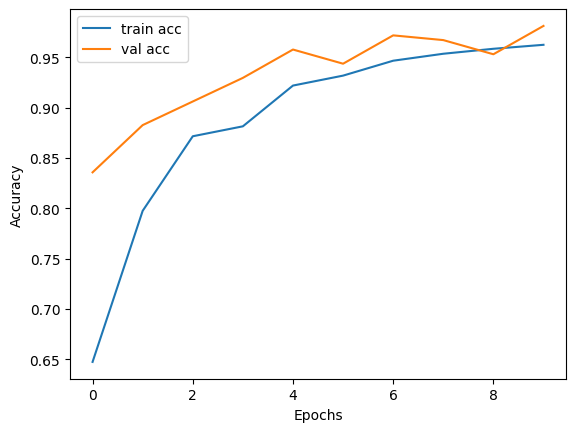

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()